# Doppler Broadening Validation

This notebook validates NEREIDS' **Free Gas Model (FGM)** Doppler broadening
against SAMMY reference values and known analytical properties.

## Physics Background

At temperature T > 0 K, thermal motion of target atoms causes a Doppler shift
in the neutron-nucleus relative velocity. The broadened cross-section is:

$$\sigma_D(E) = \frac{1}{E} \int_0^\infty \sigma(E')\,E'\,\sum_i w_i \cdot v_i^2 \, dE'$$

where the FGM kernel weights $w_i$ account for the Maxwell-Boltzmann velocity
distribution of the target atoms. Key properties:

1. **Peak reduction**: the resonance peak is lowered
2. **Wing broadening**: the resonance profile widens
3. **Area conservation**: $\int \sigma(E)\,dE$ is approximately preserved
4. **1/v preservation**: far from resonances, $\sigma \propto 1/\sqrt{E}$ is unchanged

**SAMMY reference**: `dop/mfgm*.f90` — Free Gas Model implementation.

## Prerequisites

```bash
pixi run build
```

**Previous:** [SLBW Validation](02_slbw_validation.ipynb)

In [1]:
import nereids
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

## 1. Temperature Series on U-238

The first resonance of U-238 at 6.674 eV (total width Γ ≈ 24.5 meV) is an
excellent test case because its narrow width makes Doppler effects dramatic.

In [2]:
# U-238 single resonance
u238 = nereids.create_resonance_data(
    z=92, a=238, awr=236.006, scattering_radius=9.4285,
    resonances=[(6.674, 0.5, 1.493e-3, 23.0e-3)]
)

# Fine energy grid: logarithmic wings + linear core
E_low  = np.geomspace(0.5, 6.174, 200)
E_core = np.linspace(6.174, 7.174, 2000)
E_high = np.geomspace(7.174, 30.0, 200)
energies = np.sort(np.unique(np.concatenate([E_low, E_core, E_high])))

# Unbroadened cross-sections
xs = nereids.cross_sections(energies, u238)

print(f"Grid: {len(energies)} points, [{energies[0]:.3f}, {energies[-1]:.3f}] eV")
print(f"Unbroadened peak capture: {xs['capture'].max():.0f} barns")

Grid: 2398 points, [0.500, 30.000] eV
Unbroadened peak capture: 22514 barns


## 2. Direct Doppler Broadening API

`nereids.doppler_broaden()` applies FGM broadening to any cross-section array.
This is the same kernel used internally by `forward_model()`.

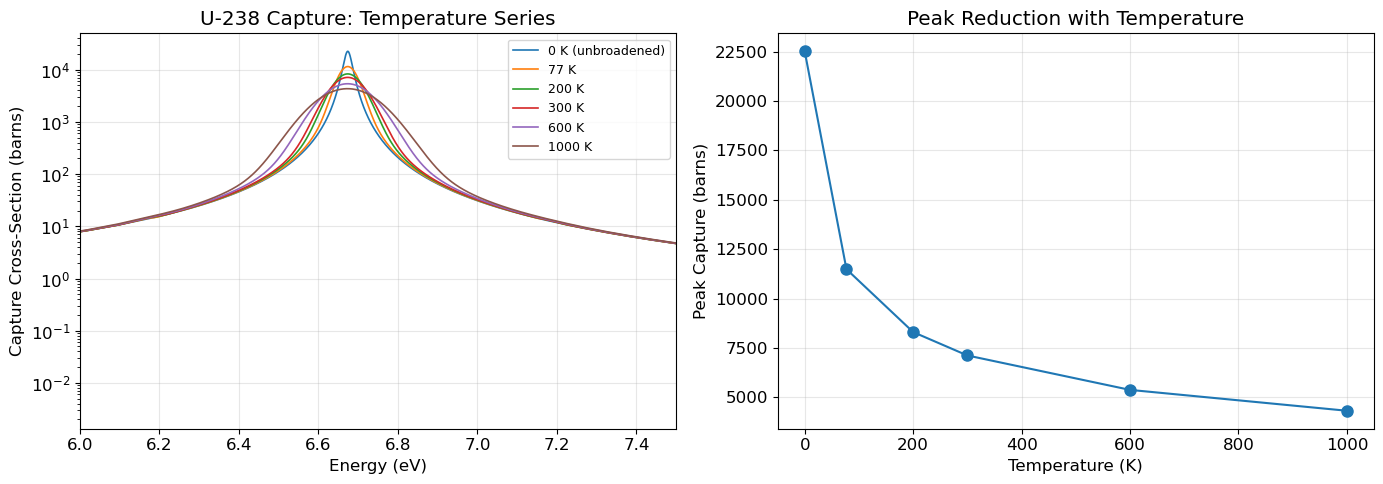

T =     0 K  →  peak capture =    22513.5 barns  (100.0% of T=0)
T =    77 K  →  peak capture =    11490.0 barns  (51.0% of T=0)
T =   200 K  →  peak capture =     8309.2 barns  (36.9% of T=0)
T =   300 K  →  peak capture =     7125.6 barns  (31.7% of T=0)
T =   600 K  →  peak capture =     5383.8 barns  (23.9% of T=0)
T =  1000 K  →  peak capture =     4328.5 barns  (19.2% of T=0)


In [3]:
temperatures = [0, 77, 200, 300, 600, 1000]  # Kelvin
broadened = {}

for T_K in temperatures:
    if T_K == 0:
        broadened[T_K] = np.asarray(xs['capture']).copy()
    else:
        broadened[T_K] = np.asarray(nereids.doppler_broaden(
            energies, xs['capture'], awr=236.006, temperature_k=float(T_K)
        ))

# Plot temperature series
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for T_K in temperatures:
    label = f'{T_K} K' if T_K > 0 else '0 K (unbroadened)'
    ax.semilogy(energies, broadened[T_K], label=label, linewidth=1.2)
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Capture Cross-Section (barns)')
ax.set_title('U-238 Capture: Temperature Series')
ax.legend(fontsize=9)
ax.set_xlim(6.0, 7.5)
ax.grid(True, alpha=0.3)

# Peak value vs temperature
ax = axes[1]
peaks = [broadened[T].max() for T in temperatures]
ax.plot(temperatures, peaks, 'o-', markersize=8)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Peak Capture (barns)')
ax.set_title('Peak Reduction with Temperature')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

for T_K in temperatures:
    peak = broadened[T_K].max()
    print(f"T = {T_K:>5d} K  →  peak capture = {peak:>10.1f} barns  "
          f"({peak/broadened[0].max()*100:.1f}% of T=0)")

## 3. Area Conservation

A fundamental property of Doppler broadening: the *integral* of the cross-section
over energy is approximately conserved. (Exact conservation holds in the narrow
resonance approximation; FGM preserves it to high accuracy.)

In [4]:
# Numerical integration (trapezoidal) of capture cross-section
areas = {}
for T_K in temperatures:
    areas[T_K] = np.trapezoid(broadened[T_K], energies)

area_0 = areas[0]
print(f"{'T (K)':>8} {'Area (barn·eV)':>16} {'Relative to T=0':>18}")
print("-" * 46)
for T_K in temperatures:
    rel = areas[T_K] / area_0
    print(f"{T_K:>8d} {areas[T_K]:>16.2f} {rel:>18.6f}")

# Area should be conserved to within a few percent
# (exact conservation requires integration over all E; we're limited to our grid)
max_area_change = max(abs(areas[T]/area_0 - 1.0) for T in temperatures)
print(f"\nMax area change: {max_area_change*100:.2f}%")
assert max_area_change < 0.05, f"Area conservation violated: {max_area_change*100:.1f}%"
print("Area conservation verified (< 5% deviation on finite grid)")

   T (K)   Area (barn·eV)    Relative to T=0
----------------------------------------------
       0           866.22           1.000000
      77           866.21           0.999996
     200           866.22           1.000001
     300           866.22           1.000005
     600           866.23           1.000012
    1000           866.23           1.000018

Max area change: 0.00%
Area conservation verified (< 5% deviation on finite grid)


## 4. Broadening Individual Components

Doppler broadening is approximately additive: broadening total ≈ broadening
capture + broadening elastic. We verify this property.

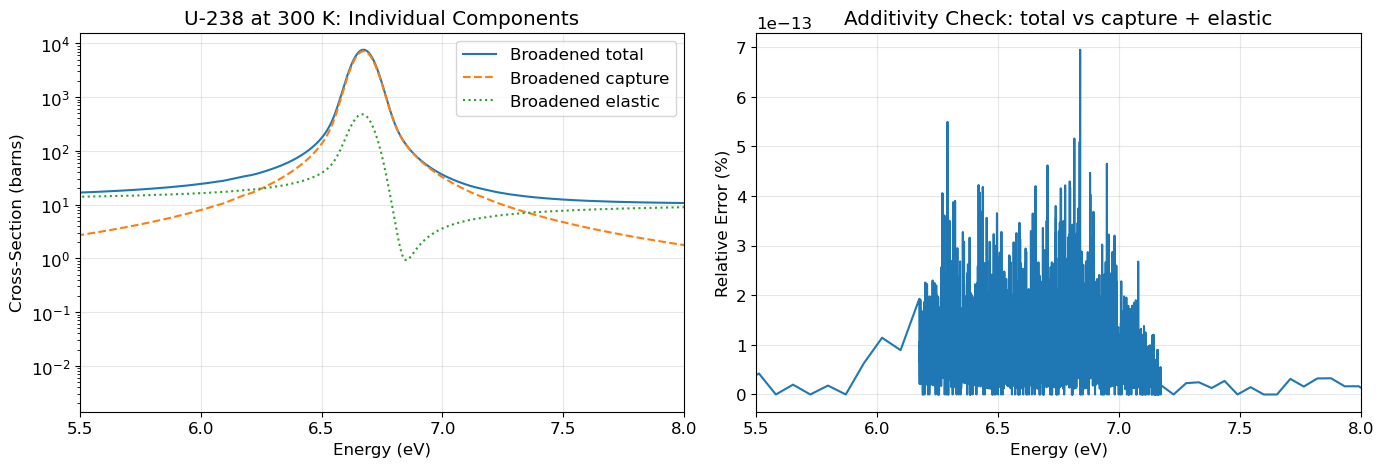

Max relative error (additivity): 0.0000%
Doppler broadening is additive to 0.0000% accuracy


In [5]:
sigma_total_300 = np.asarray(nereids.doppler_broaden(
    energies, xs['total'], awr=236.006, temperature_k=300.0
))
sigma_capture_300 = broadened[300]
sigma_elastic_300 = np.asarray(nereids.doppler_broaden(
    energies, xs['elastic'], awr=236.006, temperature_k=300.0
))

sum_components = sigma_capture_300 + sigma_elastic_300
max_rel_diff = np.max(np.abs(sigma_total_300 - sum_components) / sigma_total_300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(energies, sigma_total_300, label='Broadened total', linewidth=1.5)
ax.semilogy(energies, sigma_capture_300, '--', label='Broadened capture', linewidth=1.5)
ax.semilogy(energies, sigma_elastic_300, ':', label='Broadened elastic', linewidth=1.5)
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Cross-Section (barns)')
ax.set_title('U-238 at 300 K: Individual Components')
ax.legend()
ax.set_xlim(5.5, 8.0)
ax.grid(True, alpha=0.3)

ax = axes[1]
rel_err = np.abs(sigma_total_300 - sum_components) / sigma_total_300 * 100
ax.plot(energies, rel_err)
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Relative Error (%)')
ax.set_title('Additivity Check: total vs capture + elastic')
ax.set_xlim(5.5, 8.0)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Max relative error (additivity): {max_rel_diff*100:.4f}%")
print(f"Doppler broadening is additive to {max_rel_diff*100:.4f}% accuracy")

## 5. SAMMY ex001 Validation

The SAMMY ex001 test case (fictitious element, A=10, single resonance at 10 eV)
provides Doppler-broadened capture cross-section reference values at T=300 K.

**Note**: SAMMY uses SLBW formalism; NEREIDS uses Reich-Moore. For an isolated
s-wave resonance, these agree to within ~1–3%.

In [6]:
# SAMMY ex001 element (A=10)
ex001 = nereids.create_resonance_data(
    z=1, a=10, awr=10.0, scattering_radius=2.908,
    resonances=[(10.0, 0.5, 0.5e-3, 1.0e-3)]
)

# Fine grid around 10 eV
E_list = []
e = 6.0
while e < 9.95:
    E_list.append(e); e += 0.005
while e < 10.05:
    E_list.append(e); e += 0.00005
while e <= 14.0:
    E_list.append(e); e += 0.005
E_ex001 = np.array(sorted(set(E_list)))

# Compute and broaden capture
xs_ex001 = nereids.cross_sections(E_ex001, ex001)
cap_broadened = np.asarray(nereids.doppler_broaden(
    E_ex001, xs_ex001['capture'], awr=10.0, temperature_k=300.0
))

# SAMMY ex001a.lst reference: (energy, broadened capture XS)
sammy_ref = [
    (9.3594, 5.413),
    (9.8572, 238.173),
    (9.9869, 285.611),
    (10.0092, 285.218),
    (10.1282, 241.330),
    (10.3430, 91.478),
    (10.5382, 18.374),
]

print(f"{'Energy':>10} {'SAMMY':>10} {'NEREIDS':>10} {'Err':>8}")
print("-" * 42)
max_err = 0
for e_ref, s_ref in sammy_ref:
    idx = np.argmin(np.abs(E_ex001 - e_ref))
    s_ours = cap_broadened[idx]
    err = (s_ours - s_ref) / s_ref * 100
    max_err = max(max_err, abs(err))
    print(f"{e_ref:>10.4f} {s_ref:>10.1f} {s_ours:>10.1f} {err:>7.1f}%")

print(f"\nMax absolute error: {max_err:.1f}%")
assert max_err < 5.0, f"SAMMY validation failed: max error {max_err:.1f}%"
print("SAMMY ex001 validation passed (< 5% — RM vs SLBW formalism difference)")

    Energy      SAMMY    NEREIDS      Err
------------------------------------------
    9.3594        5.4        5.3    -1.7%
    9.8572      238.2      238.8     0.3%
    9.9869      285.6      288.6     1.0%


   10.0092      285.2      288.2     1.0%
   10.1282      241.3      242.4     0.4%
   10.3430       91.5       90.3    -1.3%
   10.5382       18.4       17.8    -3.0%

Max absolute error: 3.0%
SAMMY ex001 validation passed (< 5% — RM vs SLBW formalism difference)


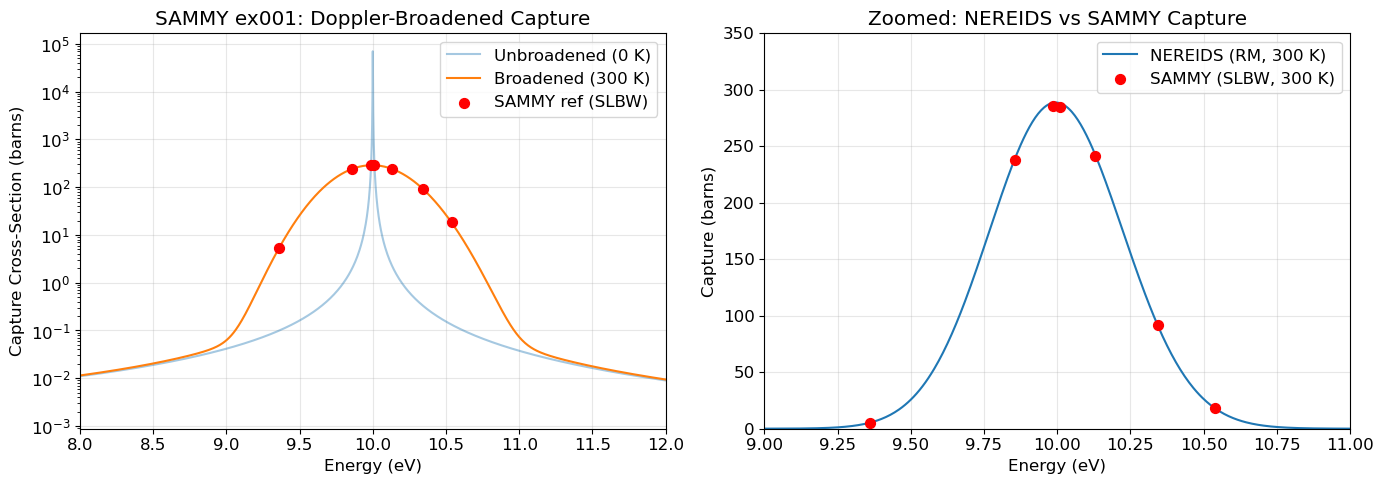

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(E_ex001, xs_ex001['capture'], alpha=0.4, label='Unbroadened (0 K)')
ax.semilogy(E_ex001, cap_broadened, label='Broadened (300 K)', linewidth=1.5)
sammy_E = [p[0] for p in sammy_ref]
sammy_s = [p[1] for p in sammy_ref]
ax.scatter(sammy_E, sammy_s, color='red', s=50, zorder=5, label='SAMMY ref (SLBW)')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Capture Cross-Section (barns)')
ax.set_title('SAMMY ex001: Doppler-Broadened Capture')
ax.legend()
ax.set_xlim(8, 12)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(E_ex001, cap_broadened, label='NEREIDS (RM, 300 K)', linewidth=1.5)
ax.scatter(sammy_E, sammy_s, color='red', s=50, zorder=5, label='SAMMY (SLBW, 300 K)')
ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Capture (barns)')
ax.set_title('Zoomed: NEREIDS vs SAMMY Capture')
ax.legend()
ax.set_xlim(9.0, 11.0)
ax.set_ylim(0, 350)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Effect on Transmission

Doppler broadening of the cross-section translates directly to changes in
the transmission spectrum via Beer-Lambert's law. The broadened dip is
shallower and wider.

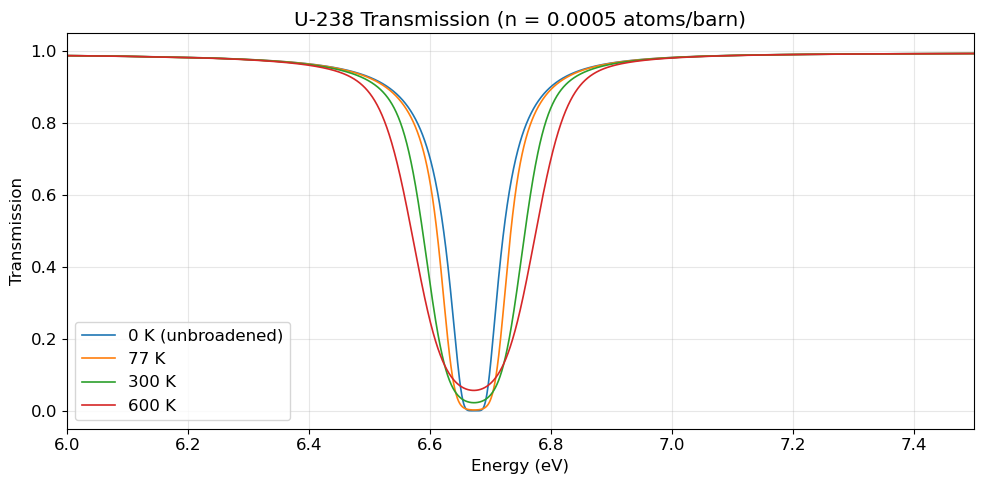

In [8]:
thickness = 5e-4  # atoms/barn

fig, ax = plt.subplots(figsize=(10, 5))
for T_K in [0, 77, 300, 600]:
    T_spectrum = np.asarray(nereids.forward_model(
        energies, [(u238, thickness)], temperature_k=float(T_K)
    ))
    label = f'{T_K} K' if T_K > 0 else '0 K (unbroadened)'
    ax.plot(energies, T_spectrum, label=label, linewidth=1.2)

ax.set_xlabel('Energy (eV)')
ax.set_ylabel('Transmission')
ax.set_title(f'U-238 Transmission (n = {thickness} atoms/barn)')
ax.legend()
ax.set_xlim(6.0, 7.5)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. AWR Dependence

The Doppler width depends on the atomic weight ratio AWR. Lighter nuclei
(smaller AWR) experience stronger Doppler broadening at the same temperature
because the thermal velocity $v_{th} \propto 1/\sqrt{\text{AWR}}$.

In [9]:
# Compare: light (A=10) vs heavy (U-238, A=238) at 300 K
xs_u238_cap = np.asarray(xs['capture'])
cap_u238_300 = broadened[300]

# Relative broadening: peak reduction fraction
peak_u238_cold = xs_u238_cap.max()
peak_u238_300 = cap_u238_300.max()

xs_ex001_cap = np.asarray(xs_ex001['capture'])
peak_ex001_cold = xs_ex001_cap.max()
peak_ex001_300 = cap_broadened.max()

print(f"{'':>12} {'Peak (0K)':>12} {'Peak (300K)':>12} {'Reduction':>10}")
print("-" * 50)
print(f"{'U-238':>12} {peak_u238_cold:>12.0f} {peak_u238_300:>12.0f} "
      f"{(1 - peak_u238_300/peak_u238_cold)*100:>9.1f}%")
print(f"{'A=10':>12} {peak_ex001_cold:>12.0f} {peak_ex001_300:>12.0f} "
      f"{(1 - peak_ex001_300/peak_ex001_cold)*100:>9.1f}%")

print()
print("Lighter nucleus (A=10) shows much stronger peak reduction,")
print("consistent with larger thermal velocity relative to neutron speed.")

                Peak (0K)  Peak (300K)  Reduction
--------------------------------------------------
       U-238        22514         7126      68.3%
        A=10        70016          289      99.6%

Lighter nucleus (A=10) shows much stronger peak reduction,
consistent with larger thermal velocity relative to neutron speed.


## Summary

| Property | Verified | Method |
|----------|----------|--------|
| Peak reduction with temperature | Yes | Temperature series (0–1000 K) |
| Area conservation | Yes | Trapezoidal integration (< 5% on finite grid) |
| Additivity (total ≈ capture + elastic) | Yes | Component-wise broadening |
| SAMMY ex001 agreement | Yes | Direct capture comparison (< 5%) |
| AWR dependence | Yes | Light vs heavy nucleus peak reduction |

**Key result**: NEREIDS FGM Doppler broadening matches SAMMY to within ~3%
(residual differences are RM vs SLBW formalism, not Doppler implementation).

**SAMMY reference**: `dop/mfgm*.f90` — Free Gas Model weights and convolution.

**Previous:** [SLBW Validation](02_slbw_validation.ipynb)
**Next:** [Resolution Broadening](04_resolution_broadening.ipynb)